# Business Entity Resolution: Initial EDA

This notebook performs a memory-safe first pass over the Amazon ML Challenge 2026 data. It focuses on the questions that affect an entity-resolution system most: dataset scale, missingness, country shift, multilingual text, target cardinality, and the strength of simple normalized string signals.

Challenge constraints used here:
- Source 1 is the deduplicated reference; each Source 1 record may have zero, one, or many matches in Sources 2 and 3.
- The score is macro F0.5, so precision and correct singleton decisions matter heavily.
- France appears only in test; country must be treated as an open-set label.
- External business lookup, geocoding, and internet augmentation are prohibited. This notebook uses only the supplied files.


In [1]:
from pathlib import Path
from collections import Counter
import json
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 90)

ROOT = Path.cwd()
DATA = ROOT / 'dataset'
CHUNK_SIZE = 250_000
PAIR_SAMPLE_SIZE = 50_000
RNG = np.random.default_rng(42)

SOURCE_FILES = {
    'train_s1': DATA / 'train/train_source1.tsv',
    'train_s2': DATA / 'train/train_source2.tsv',
    'train_s3': DATA / 'train/train_source3.tsv',
    'test_s1': DATA / 'test/test_source1.tsv',
    'test_s2': DATA / 'test/test_source2.tsv',
    'test_s3': DATA / 'test/test_source3.tsv',
}
GT_FILE = DATA / 'train/train_ground_truth.tsv'

missing = [str(p) for p in [*SOURCE_FILES.values(), GT_FILE] if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing expected files: {missing}')

print(f'Working directory: {ROOT}')
print(f'Chunk size: {CHUNK_SIZE:,} rows')


Working directory: /home/laalenthika/Downloads/student_resource
Chunk size: 250,000 rows


## 1. File inventory and schema check

The raw TSV files total several gigabytes, so the main profiling pass reads them in chunks rather than loading all sources into memory at once.


In [2]:
def count_data_rows(path: Path) -> int:
    with path.open('rb') as fh:
        return max(sum(block.count(b'\n') for block in iter(lambda: fh.read(8 * 1024 * 1024), b'')) - 1, 0)

inventory = []
for label, path in {**SOURCE_FILES, 'train_ground_truth': GT_FILE}.items():
    header = pd.read_csv(path, sep='\t', nrows=0).columns.tolist()
    inventory.append({
        'file': label,
        'rows': count_data_rows(path),
        'size_mb': path.stat().st_size / 1024**2,
        'columns': ', '.join(header),
    })
inventory_df = pd.DataFrame(inventory)
display(inventory_df.style.format({'rows': '{:,.0f}', 'size_mb': '{:,.1f}'}))
print(f"Total data rows: {inventory_df['rows'].sum():,.0f}")
print(f"Total size: {inventory_df['size_mb'].sum()/1024:,.2f} GiB")


,file,rows,size_mb,columns
0,train_s1,"2,206,821",200.3,"entity_id, business_name, business_address, country"
1,train_s2,"5,034,616",466.6,"entity_id, business_name, business_address, country"
2,train_s3,"5,285,603",480.4,"entity_id, business_name, business_address, country"
3,test_s1,"1,732,544",166.9,"entity_id, business_name, business_address, country"
4,test_s2,"4,887,273",485.9,"entity_id, business_name, business_address, country"
5,test_s3,"5,082,316",482.6,"entity_id, business_name, business_address, country"
6,train_ground_truth,"2,206,821",121.1,"source1_entity_id, matched_entity_ids"


Total data rows: 26,435,994
Total size: 2.35 GiB


## 2. Streaming source profiles

For each source, this pass measures blank fields, country counts, identifier-prefix violations, non-ASCII text, and name/address length. Blank strings are preserved rather than silently converted to NaN.


In [3]:
EXPECTED_PREFIX = {'train_s1': 'S1-', 'train_s2': 'S2-', 'train_s3': 'S3-',
                   'test_s1': 'S1-', 'test_s2': 'S2-', 'test_s3': 'S3-'}

def profile_source(label: str, path: Path, chunk_size: int = CHUNK_SIZE):
    total = 0
    blank = Counter()
    countries = Counter()
    prefix_violations = 0
    within_chunk_duplicate_ids = 0
    non_ascii_name = 0
    non_ascii_address = 0
    length_sum = Counter()
    length_max = Counter()
    length_samples = {'business_name': [], 'business_address': []}

    for chunk_no, chunk in enumerate(pd.read_csv(
        path, sep='\t', dtype=str, keep_default_na=False,
        chunksize=chunk_size, on_bad_lines='error'
    )):
        total += len(chunk)
        for col in ['entity_id', 'business_name', 'business_address', 'country']:
            s = chunk[col].astype(str)
            blank[col] += int(s.str.strip().eq('').sum())
        countries.update(chunk['country'].str.strip().replace('', '<blank>').value_counts().to_dict())
        prefix_violations += int((~chunk['entity_id'].str.startswith(EXPECTED_PREFIX[label])).sum())
        within_chunk_duplicate_ids += int(chunk['entity_id'].duplicated().sum())

        for col in ['business_name', 'business_address']:
            s = chunk[col].astype(str)
            lengths = s.str.len()
            length_sum[col] += int(lengths.sum())
            length_max[col] = max(length_max[col], int(lengths.max()))
            if chunk_no < 8:
                take = min(2_500, len(lengths))
                idx = RNG.choice(len(lengths), size=take, replace=False)
                length_samples[col].extend(lengths.iloc[idx].tolist())
        non_ascii_name += int(chunk['business_name'].str.contains(r'[^\x00-\x7F]', regex=True).sum())
        non_ascii_address += int(chunk['business_address'].str.contains(r'[^\x00-\x7F]', regex=True).sum())

    row = {
        'file': label, 'rows': total,
        'blank_name_pct': 100 * blank['business_name'] / total,
        'blank_address_pct': 100 * blank['business_address'] / total,
        'blank_country_pct': 100 * blank['country'] / total,
        'non_ascii_name_pct': 100 * non_ascii_name / total,
        'non_ascii_address_pct': 100 * non_ascii_address / total,
        'avg_name_chars': length_sum['business_name'] / total,
        'avg_address_chars': length_sum['business_address'] / total,
        'max_name_chars': length_max['business_name'],
        'max_address_chars': length_max['business_address'],
        'bad_id_prefix': prefix_violations,
        'duplicate_ids_within_chunks': within_chunk_duplicate_ids,
    }
    return row, countries, length_samples

profiles, country_counts, sampled_lengths = [], {}, {}
for label, path in SOURCE_FILES.items():
    print(f'Profiling {label} ...', flush=True)
    row, countries, lengths = profile_source(label, path)
    profiles.append(row)
    country_counts[label] = countries
    sampled_lengths[label] = lengths

profile_df = pd.DataFrame(profiles)
display(profile_df.style.format({
    'rows': '{:,.0f}',
    'blank_name_pct': '{:.3f}%', 'blank_address_pct': '{:.3f}%', 'blank_country_pct': '{:.3f}%',
    'non_ascii_name_pct': '{:.2f}%', 'non_ascii_address_pct': '{:.2f}%',
    'avg_name_chars': '{:.1f}', 'avg_address_chars': '{:.1f}',
}))

country_df = (pd.DataFrame(country_counts).fillna(0).astype('int64')
              .rename_axis('country').reset_index())
display(country_df.style.format({c: '{:,.0f}' for c in country_df.columns if c != 'country'}))


Profiling train_s1 ...


Profiling train_s2 ...


Profiling train_s3 ...


Profiling test_s1 ...


Profiling test_s2 ...


Profiling test_s3 ...


,file,rows,blank_name_pct,blank_address_pct,blank_country_pct,non_ascii_name_pct,non_ascii_address_pct,avg_name_chars,avg_address_chars,max_name_chars,max_address_chars,bad_id_prefix,duplicate_ids_within_chunks
0,train_s1,"2,206,821",0.000%,0.000%,0.000%,0.00%,0.03%,24.0,52.1,105,256,0,0
1,train_s2,"5,034,616",0.000%,3.356%,0.000%,15.19%,9.50%,25.1,46.2,104,249,0,0
2,train_s3,"5,285,603",0.000%,3.328%,0.000%,11.48%,9.02%,25.2,46.7,123,240,0,0
3,test_s1,"1,732,544",0.000%,0.000%,0.000%,2.35%,4.26%,23.8,57.2,92,268,0,0
4,test_s2,"4,887,273",0.000%,2.648%,0.000%,18.99%,14.75%,25.7,50.4,102,269,0,0
5,test_s3,"5,082,316",0.000%,2.678%,0.000%,14.51%,14.35%,25.7,48.7,103,267,0,0


,country,train_s1,train_s2,train_s3,test_s1,test_s2,test_s3
0,US,"1,323,633","3,016,817","3,170,056","663,106","1,871,330","1,945,701"
1,India,"883,188","2,017,799","2,115,547","809,986","2,312,565","2,405,000"
2,France,0,0,0,"259,452","703,378","731,615"


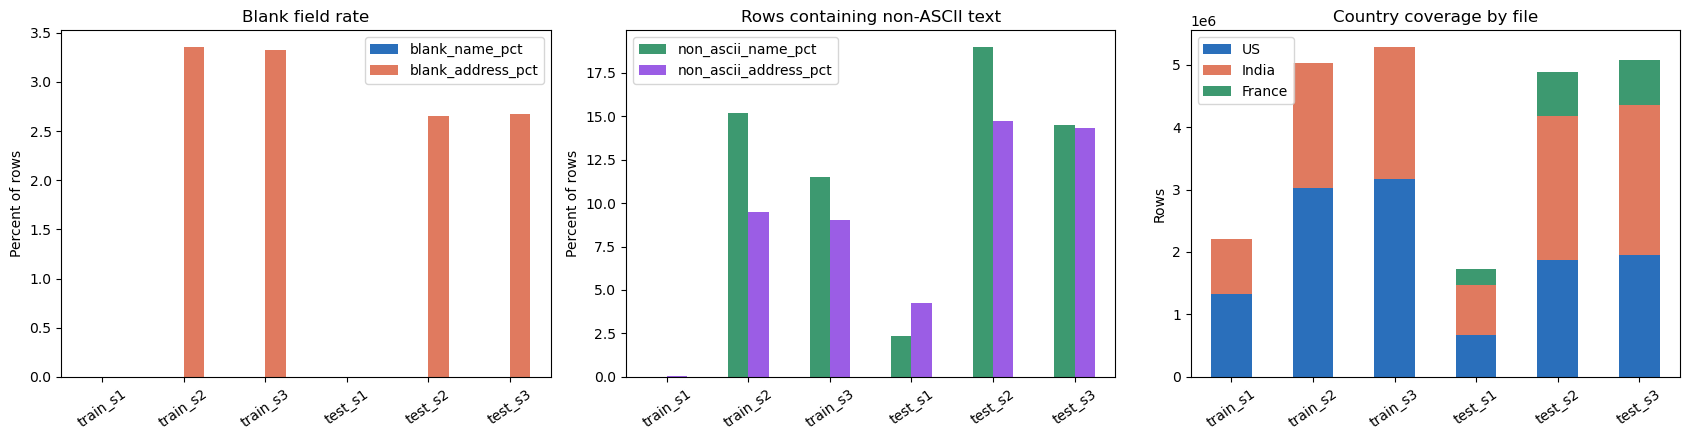

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
profile_df.set_index('file')[['blank_name_pct', 'blank_address_pct']].plot.bar(
    ax=axes[0], color=['#2A6FBB', '#E07A5F'])
axes[0].set_title('Blank field rate')
axes[0].set_ylabel('Percent of rows')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=35)

profile_df.set_index('file')[['non_ascii_name_pct', 'non_ascii_address_pct']].plot.bar(
    ax=axes[1], color=['#3D9970', '#9B5DE5'])
axes[1].set_title('Rows containing non-ASCII text')
axes[1].set_ylabel('Percent of rows')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=35)

country_plot = country_df.set_index('country').T
country_plot.plot.bar(stacked=True, ax=axes[2], color=['#2A6FBB', '#E07A5F', '#3D9970'])
axes[2].set_title('Country coverage by file')
axes[2].set_ylabel('Rows')
axes[2].tick_params(axis='x', rotation=35)
axes[2].legend()
plt.tight_layout()
plt.show()


## 3. Ground-truth cardinality

Macro F0.5 is calculated per Source 1 entity. The number of singleton rows and the distribution of one-to-many matches therefore determine how conservative the model should be.


,metric,value
0,rows,2.206821e+06
1,links,7.638365e+06
2,avg_links_per_s1,3.461253e+00
3,singleton_rows,1.232470e+05
4,singleton_pct,5.584821e+00
5,duplicate_links,0.000000e+00
6,invalid_links,0.000000e+00
7,bad_s1_prefix,0.000000e+00


,matches_per_s1,source1_rows,percent
0,0,"123,247",5.58%
1,1,"119,157",5.40%
2,2,"375,212",17.00%
3,3,"530,841",24.05%
4,4,"484,115",21.94%
5,5,"321,957",14.59%
6,6,"164,868",7.47%
7,7,"63,968",2.90%
8,8,"18,680",0.85%
9,9,"4,205",0.19%


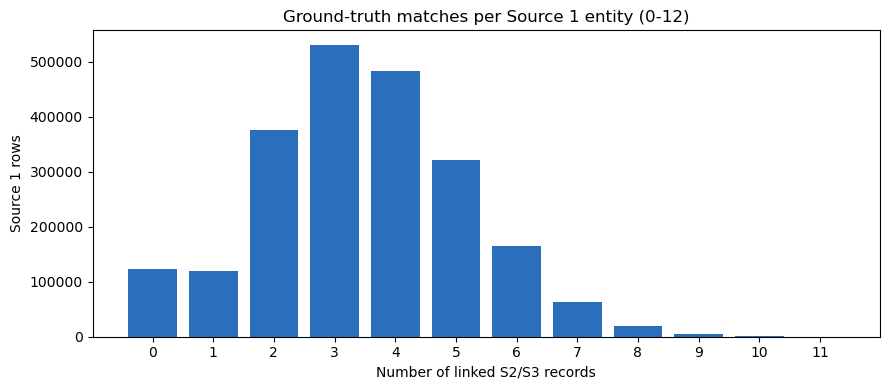

In [5]:
def profile_ground_truth(path: Path, chunk_size: int = CHUNK_SIZE):
    match_count_dist = Counter()
    s2_count_dist = Counter()
    s3_count_dist = Counter()
    total_rows = total_links = duplicate_links = invalid_links = 0
    bad_s1_prefix = 0
    for chunk in pd.read_csv(path, sep='\t', dtype=str, keep_default_na=False, chunksize=chunk_size):
        total_rows += len(chunk)
        bad_s1_prefix += int((~chunk['source1_entity_id'].str.startswith('S1-')).sum())
        for raw in chunk['matched_entity_ids']:
            ids = [x.strip() for x in raw.split(',') if x.strip()]
            s2 = sum(x.startswith('S2-') for x in ids)
            s3 = sum(x.startswith('S3-') for x in ids)
            match_count_dist[len(ids)] += 1
            s2_count_dist[s2] += 1
            s3_count_dist[s3] += 1
            total_links += len(ids)
            duplicate_links += len(ids) - len(set(ids))
            invalid_links += sum(not (x.startswith('S2-') or x.startswith('S3-')) for x in ids)
    return {
        'rows': total_rows, 'links': total_links,
        'avg_links_per_s1': total_links / total_rows,
        'singleton_rows': match_count_dist[0],
        'singleton_pct': 100 * match_count_dist[0] / total_rows,
        'duplicate_links': duplicate_links, 'invalid_links': invalid_links,
        'bad_s1_prefix': bad_s1_prefix,
        'match_count_dist': match_count_dist,
        's2_count_dist': s2_count_dist, 's3_count_dist': s3_count_dist,
    }

gt_profile = profile_ground_truth(GT_FILE)
summary_keys = ['rows', 'links', 'avg_links_per_s1', 'singleton_rows', 'singleton_pct',
                'duplicate_links', 'invalid_links', 'bad_s1_prefix']
display(pd.DataFrame({'metric': summary_keys, 'value': [gt_profile[k] for k in summary_keys]}))

dist = pd.Series(gt_profile['match_count_dist']).sort_index()
dist_table = pd.DataFrame({'matches_per_s1': dist.index, 'source1_rows': dist.values})
dist_table['percent'] = 100 * dist_table['source1_rows'] / dist_table['source1_rows'].sum()
display(dist_table.head(20).style.format({'source1_rows': '{:,.0f}', 'percent': '{:.2f}%'}))

fig, ax = plt.subplots(figsize=(9, 4))
plot_dist = dist[dist.index <= 12]
ax.bar(plot_dist.index.astype(str), plot_dist.values, color='#2A6FBB')
ax.set_title('Ground-truth matches per Source 1 entity (0-12)')
ax.set_xlabel('Number of linked S2/S3 records')
ax.set_ylabel('Source 1 rows')
plt.tight_layout()
plt.show()


## 4. Sampled true-pair signal analysis

The following section takes a deterministic sample of labeled Source 1 entities, retrieves only their linked Source 2/3 records by streaming through the source files, and measures simple normalized comparisons. This is not a model or a score; it reveals which fields can support blocking and which require fuzzy or multilingual handling.


Sampled Source 1 entities: 50,000
True linked pairs in sample: 172,731


Pairs with an unretrieved record: 0


,metric,value
0,Exact normalized name,21.53%
1,Exact normalized address,8.30%
2,Exact name or address,28.56%
3,Same country,100.00%
4,Median name token Jaccard,66.67%
5,Median address token Jaccard,62.50%


,0.000000,0.100000,0.250000,0.500000,0.750000,0.900000,1.000000
name_jaccard,0.000,0.000,0.500,0.667,1.000,1.000,1.000
address_jaccard,0.000,0.250,0.429,0.625,0.786,1.000,1.000


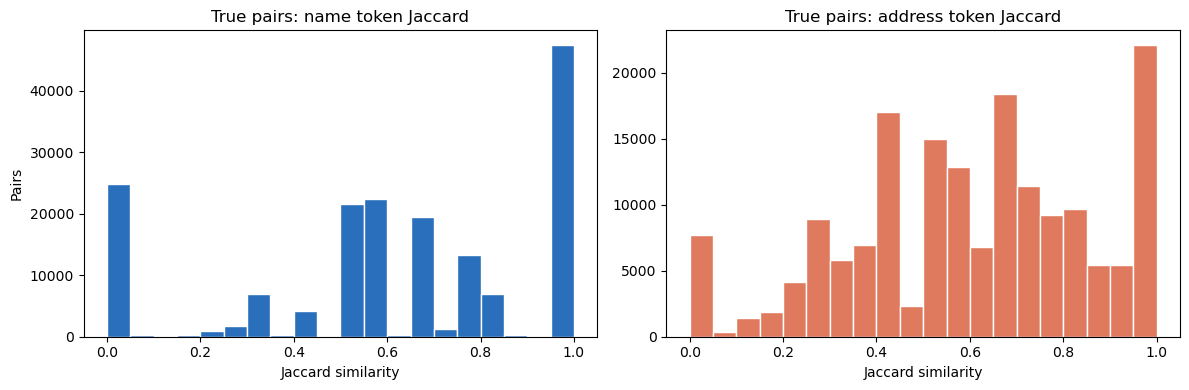

,source1_entity_id,matched_id,s1_name,other_name,s1_address,other_address,name_jaccard,address_jaccard
89926,S1-523030302,S3-544626654,Sr & Brothers Limited,Sr & Bsrtréds Limited,"Hooghly, West Bengal, Arambagh, C/O-Malay Kanti Konar Mouchak, Hospital More, W/N-05","C/o-malay Kanti Konar Mouchak, Hospital More, W/n-05, Arambagh, Hooghly, WB",0.600000,0.812500
135600,S1-485045189,S2-32824702,"Dasonva Acres, LLC","Dasonva Acres,","9088 Tavernor Road, Wilton, CA","088 TAVERNOR ROAD, WILTON, CA",0.666667,0.666667
25424,S1-28736184,S2-392483196,Jan Foundation Limited,Jan Foundation,"G 190, Lajpat Nagar, Sahibabad, Ghaziabad, Uttar Pradesh","G 190, LAJPAT NAGAR, SAHIBABAD, GHAZIABAD, उत्तर प्रदेश",0.666667,0.461538
151897,S1-358107461,S2-975899475,Western Animal Hospital PC,Western Animal Hospital LLC,"1339 Elrado Street, Burlington, NC","1339 ELRADO ST, BURLINGTON, NC",0.600000,0.666667
11975,S1-743864993,S2-707208692,Christ Church,christchurch.com,"NC, Lexington, 414 Mountain View Church Road","414 MOUNTAIN VIEW CHURCH RD, LEXINGTON, NC",0.000000,0.750000
112912,S1-18359760,S2-351329105,Mastroianni Peoples LLC,L.L.C. MASTROIANNI PÉOPLES,"126 Resaca Drive, Midvale, UT","0126 RESACA DRIVE, MIDVALE, UT",0.166667,0.666667
47974,S1-556447507,S2-910378574,Beacon,Beac0n,"3536 Watt Avenue, Unit APT 103A, Sacramento, CA","3536 WATT AVE, CA, N/A, SACRAMENTO",0.000000,0.363636
52706,S1-564395844,S3-162791567,Route 6 Nails,Route 6 Center,"Smithville, Unit B, 102 Pathfinders Way, TX",,0.500000,0.000000
36958,S1-714329848,S2-45655996,Ashtavinayak Fruit Private Limited,@ashtavinayakfruit,"H No 684, Flat No 4, Gali No 6, Chattarpur, South West Delhi, Delhi","H.NO 684 , FLAT NO 4, GALI NO 6, CHATTARPUR, SOUTH WEST DELHI, दिल्ली",0.000000,0.846154
121871,S1-534148832,S2-838271768,Galaxy Software Private Limited,Galaxy [Software],"88 Ground Floor Avtar Enclave Paschim Vihar, New Delhi, North Delhi, Delhi","NO #88 GROUND FLOOR AVTAR ENCLAVE PASCHIM VIHAR, NEW DELHI, Delhi",0.500000,0.818182


In [6]:
def normalize_text(value: str) -> str:
    value = unicodedata.normalize('NFKC', str(value)).casefold()
    value = value.replace('&', ' and ')
    value = re.sub(r'[^\w]+', ' ', value, flags=re.UNICODE)
    return ' '.join(value.split())

def token_jaccard(left: str, right: str) -> float:
    a, b = set(left.split()), set(right.split())
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

gt_sample = pd.read_csv(GT_FILE, sep='\t', dtype=str, keep_default_na=False, nrows=PAIR_SAMPLE_SIZE)
gt_sample['matched_id'] = gt_sample['matched_entity_ids'].str.split(',')
pairs = gt_sample.explode('matched_id')
pairs['matched_id'] = pairs['matched_id'].str.strip()
pairs = pairs[pairs['matched_id'].ne('')][['source1_entity_id', 'matched_id']]
wanted_s1 = set(gt_sample['source1_entity_id'])
wanted_other = set(pairs['matched_id'])
print(f'Sampled Source 1 entities: {len(gt_sample):,}')
print(f'True linked pairs in sample: {len(pairs):,}')

def retrieve_records(path: Path, wanted_ids: set[str]) -> pd.DataFrame:
    found = []
    for chunk in pd.read_csv(path, sep='\t', dtype=str, keep_default_na=False, chunksize=CHUNK_SIZE):
        selected = chunk[chunk['entity_id'].isin(wanted_ids)]
        if len(selected):
            found.append(selected)
    if not found:
        return pd.DataFrame(columns=['entity_id', 'business_name', 'business_address', 'country'])
    return pd.concat(found, ignore_index=True)

sample_s1 = retrieve_records(SOURCE_FILES['train_s1'], wanted_s1)
sample_other = pd.concat([
    retrieve_records(SOURCE_FILES['train_s2'], wanted_other),
    retrieve_records(SOURCE_FILES['train_s3'], wanted_other),
], ignore_index=True)

s1_cols = {'entity_id': 'source1_entity_id', 'business_name': 's1_name',
           'business_address': 's1_address', 'country': 's1_country'}
other_cols = {'entity_id': 'matched_id', 'business_name': 'other_name',
              'business_address': 'other_address', 'country': 'other_country'}
pair_df = (pairs.merge(sample_s1.rename(columns=s1_cols), on='source1_entity_id', how='left')
                .merge(sample_other.rename(columns=other_cols), on='matched_id', how='left'))
missing_records = pair_df[['s1_name', 'other_name']].isna().any(axis=1).sum()
print(f'Pairs with an unretrieved record: {missing_records:,}')

for col in ['s1_name', 'other_name', 's1_address', 'other_address']:
    pair_df[col + '_norm'] = pair_df[col].fillna('').map(normalize_text)

pair_df['exact_name'] = (pair_df['s1_name_norm'] != '') & (pair_df['s1_name_norm'] == pair_df['other_name_norm'])
pair_df['exact_address'] = (pair_df['s1_address_norm'] != '') & (pair_df['s1_address_norm'] == pair_df['other_address_norm'])
pair_df['exact_either'] = pair_df['exact_name'] | pair_df['exact_address']
pair_df['country_equal'] = pair_df['s1_country'] == pair_df['other_country']
pair_df['name_jaccard'] = [token_jaccard(a, b) for a, b in zip(pair_df['s1_name_norm'], pair_df['other_name_norm'])]
pair_df['address_jaccard'] = [token_jaccard(a, b) for a, b in zip(pair_df['s1_address_norm'], pair_df['other_address_norm'])]

signal_summary = pd.DataFrame({
    'metric': ['Exact normalized name', 'Exact normalized address', 'Exact name or address',
               'Same country', 'Median name token Jaccard', 'Median address token Jaccard'],
    'value': [pair_df['exact_name'].mean(), pair_df['exact_address'].mean(), pair_df['exact_either'].mean(),
              pair_df['country_equal'].mean(), pair_df['name_jaccard'].median(), pair_df['address_jaccard'].median()]
})
display(signal_summary.style.format({'value': '{:.2%}'}))

quantiles = pair_df[['name_jaccard', 'address_jaccard']].quantile([0, .1, .25, .5, .75, .9, 1]).T
display(quantiles.style.format('{:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pair_df['name_jaccard'], bins=20, color='#2A6FBB', edgecolor='white')
axes[0].set_title('True pairs: name token Jaccard')
axes[0].set_xlabel('Jaccard similarity')
axes[0].set_ylabel('Pairs')
axes[1].hist(pair_df['address_jaccard'], bins=20, color='#E07A5F', edgecolor='white')
axes[1].set_title('True pairs: address token Jaccard')
axes[1].set_xlabel('Jaccard similarity')
plt.tight_layout()
plt.show()

display(pair_df.loc[~pair_df['exact_either'], [
    'source1_entity_id', 'matched_id', 's1_name', 'other_name', 's1_address', 'other_address',
    'name_jaccard', 'address_jaccard'
]].sample(min(12, (~pair_df['exact_either']).sum()), random_state=42))


In [7]:
first_50_ids = set(gt_sample.head(50)['source1_entity_id'])
first_50_addresses = pair_df.loc[
    pair_df['source1_entity_id'].isin(first_50_ids),
    ['source1_entity_id', 'matched_id', 's1_address', 'other_address']
].copy()

print(first_50_addresses.to_string(index=False))


source1_entity_id   matched_id                                                                                                                 s1_address                                                                                                          other_address
        S1-965667 S2-681193310                                                                                           85 Wayne Avenue, Ticonderoga, NY                                                                                                                       
        S1-965667 S2-743505751                                                                                           85 Wayne Avenue, Ticonderoga, NY                                                                                                                       
        S1-965667 S3-775321672                                                                                           85 Wayne Avenue, Ticonderoga, NY                            

## 5. What this means for the first baseline

1. **Build country-aware but open-set blocking.** Use country as a strong partition when present, but derive supported values from the files and provide a generic path for unseen labels such as France.
2. **Keep separate name and address retrieval channels.** Missing addresses and noisy names mean neither field can be the only blocker. Union candidates from normalized character n-grams, word/token keys, postal fragments, and numeric address components.
3. **Preserve Unicode.** NFKC plus case-folding is a safe first normalization. Do not drop non-ASCII text; multilingual names and addresses are informative. Transliteration should be a parallel feature rather than a destructive replacement.
4. **Optimize candidate recall before classifier tuning.** Measure blocking recall on a held-out group split, then control candidate-set size. The submitted candidate file must be the exact final set scored by the model.
5. **Use conservative, calibrated decisions.** Macro F0.5 and singleton credit favor high precision. Tune thresholds per Source 1 entity and include an explicit empty-match decision.
6. **Split by entity, not by pair.** Put all pairs belonging to a Source 1 entity in the same fold to avoid leakage. Also report performance by country, singleton/non-singleton status, source (S2 vs S3), and match cardinality.

Recommended next implementation: a high-recall blocking baseline using normalized TF-IDF character n-grams (separate name and address indices) plus exact numeric/postal tokens, followed by a lightweight pair classifier using string similarities and missingness indicators.
